In [52]:
# 导入相关库
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim

In [54]:
transform = transforms.Compose([
    transforms.ToTensor(),         #将numpy类型转换为Tensor张量
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))    #归一化预处理，加速模型训练
])

In [56]:
# 下载训练集及测试集
trainset = datasets.CIFAR10(root = './CIFAR10', train = True, download = True, transform = transform)
testset = datasets.CIFAR10(root = './CIFAR10', train = False, download = True, transform = transform)

In [57]:
# 批量读取数据
from torch.utils.data.dataloader import DataLoader
SIZE = 32
train_loader = DataLoader(trainset, batch_size = SIZE, shuffle = True, num_workers = 8, pin_memory = True)
test_loader = DataLoader(testset, batch_size = SIZE, shuffle = True, num_workers = 8, pin_memory = True)


In [58]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [59]:
def imshow(images):
    images = images / 2 + 0.5  # 逆正则化
    np_images = images.numpy() # Tensor转换为numpy
    plt.imshow(np.transpose(np_images, (1, 2, 0))) # 改变通道顺序
    plt.show()

In [60]:
images, labels = next(iter(train_loader))

torch.Size([32, 3, 32, 32])
torch.Size([32])


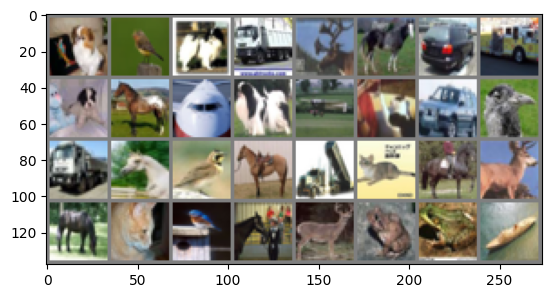

  dog  bird   dog truck  deer horse   car truck   dog horse plane   dog plane   cat   car  bird truck horse  bird horse truck   cat horse  deer horse   cat  bird horse  deer  frog  frog  ship


In [61]:
print(images.shape)
print(labels.shape)
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[i]] for i in range(SIZE)))

In [62]:
# 搭建网络模型
# 特征图尺寸的计算公式 ： 【（原图片尺寸 - 卷积核尺寸） / 步长】 + 1
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 卷积层1, 输入32 * 32 * 3, 计算（32 - 5）/ 1 + 1
        self.conv1 = nn.Conv2d(3, 6, 5)   # 输入通道数：3， 输出通道数：6， 卷积核大小5 * 5
        # 池化层, 输入28 * 28 * 6, 计算 28 / 2 = 14, 则通过max_pool1层输出结果为 14 * 14 * 6
        self.pool = nn.MaxPool2d(2, 2)  # 窗口 2 * 2 , 步长为2
        # 卷积层2, 输入 14 * 14 * 6， 计算（14 - 5） / 1 + 1 = 10, 则通过卷积层2输出结果为 10 * 10 * 16
        self.conv2 = nn.Conv2d(6, 16, 5)
        # 全连接层1
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # 全连接层2
        self.fc2 = nn.Linear(120, 84)
        # 全连接层3
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        # 卷积1
        x = self.pool(F.relu(self.conv1(x)))
        # 卷积2
        x = self.pool(F.relu(self.conv2(x)))
        # 改变shape
        x = x.view(-1, 16 * 5 * 5)
        # 全连接层1
        x = F.relu(self.fc1(x))
        # 全连接层2
        x = F.relu(self.fc2(x))
        # 全连接层3
        x = self.fc3(x)
        return x
        

In [64]:
# 创建模型
net = Net().to('cuda')

In [65]:
# 定义优化器及损失函数
criterion = nn.CrossEntropyLoss() # 交叉熵损失函数
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [69]:
num_iter = 200
for i in range(num_iter):
    train_loss = 0.0
    for j, (datas, labels) in enumerate(train_loader):
        datas, labels = datas.to('cuda'), labels.to('cuda')
        # 梯度置零
        optimizer.zero_grad()
        # 训练
        outputs = net(datas)
        # 计算损失
        loss = criterion(outputs, labels)
        # 反向传播
        loss.backward()
        # 参数更新
        optimizer.step()
        # 累计损失
        train_loss += loss.item()
    print("Num_iter : %d, Batch : %5d, Loss : %.3f"%(i + 1, j + 1, train_loss / len(train_loader.dataset)))

Num_iter : 1, Batch :  1563, Loss : 0.068
Num_iter : 2, Batch :  1563, Loss : 0.055
Num_iter : 3, Batch :  1563, Loss : 0.049
Num_iter : 4, Batch :  1563, Loss : 0.046
Num_iter : 5, Batch :  1563, Loss : 0.043
Num_iter : 6, Batch :  1563, Loss : 0.041
Num_iter : 7, Batch :  1563, Loss : 0.039
Num_iter : 8, Batch :  1563, Loss : 0.037
Num_iter : 9, Batch :  1563, Loss : 0.036
Num_iter : 10, Batch :  1563, Loss : 0.035
Num_iter : 11, Batch :  1563, Loss : 0.034
Num_iter : 12, Batch :  1563, Loss : 0.033
Num_iter : 13, Batch :  1563, Loss : 0.032
Num_iter : 14, Batch :  1563, Loss : 0.031
Num_iter : 15, Batch :  1563, Loss : 0.030
Num_iter : 16, Batch :  1563, Loss : 0.029
Num_iter : 17, Batch :  1563, Loss : 0.029
Num_iter : 18, Batch :  1563, Loss : 0.028
Num_iter : 19, Batch :  1563, Loss : 0.027
Num_iter : 20, Batch :  1563, Loss : 0.026
Num_iter : 21, Batch :  1563, Loss : 0.026
Num_iter : 22, Batch :  1563, Loss : 0.025
Num_iter : 23, Batch :  1563, Loss : 0.024
Num_iter : 24, Batch

In [87]:
# 保存模型
PATH = r'D:\model.path'
torch.save(net.state_dict(), PATH)

In [91]:
model = Net()
model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [97]:
# 测试
correct = 0
total = 0
with torch.no_grad():
    for i, (datas, labels) in enumerate(test_loader):
        outputs = model(datas)
        _, predicted = torch.max(outputs.data, dim = 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()
    print("Accuracy = {:.3f}%".format(correct / total * 100))


Accuracy = 59.060%


In [103]:
# 显示每一类预测的概率
class_correct = list(0. for i in range(10))
total = list(0. for i in range(10))
with torch.no_grad():
    for (images, labels) in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs, dim = 1)
        c = (predicted == labels).squeeze()
        if labels.shape[0] == 32:
            for i in range(SIZE):
                label = labels[i]
                class_correct[label] += c[i].item()
                total[label] += 1
# 输出正确率
for i in range(10):
    print("Accuracy : %5s : %2d  % %" % (classes[i], 100 * class_correct[i] / total[i]))

TypeError: not enough arguments for format string